In [1]:
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
df1 = pd.read_csv('../data/CRMLSSold202401_filled.csv')
df2 = pd.read_csv('../data/CRMLSSold202402_filled.csv')
df3 = pd.read_csv('../data/CRMLSSold202501_filled.csv')
df4 = pd.read_csv('../data/CRMLSSold202502.csv')
df5 = pd.read_csv('../data/CRMLSSold202601.csv')
df6 = pd.read_csv('../data/CRMLSSold202602.csv')

/var/folders/3l/3v_d6vqj7892stpd98hwf1ym0000gn/T/ipykernel_11506/2253679263.py:6: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df5 = pd.read_csv('../data/CRMLSSold202601.csv')


In [3]:
df = pd.concat([df1, df2, df3, df4, df5, df6], axis=0, ignore_index=True)
df = df.drop(['ListPrice', 'OriginalListPrice'], axis=1)

In [4]:
# Restricting analysis according to Project Document
df = df[df['PropertyType'] == 'Residential']
df = df[df['PropertySubType'] == 'SingleFamilyResidence']

##### Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize. 
- ClosePrice - Decimal
- LivingArea - Decimal
- Bedrooms (BedroomsTotal) - Int32
- Bathrooms (BathroomsTotalInteger) - Int32
- LotSize (LotSizeSquareFeet) - Decimal

In [5]:
# function to remove outliers based on IQR
def remove_outliers(data, col_name):
    Q1 = data[col_name].quantile(0.25)
    Q3 = data[col_name].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return data[(data[col_name] >= lower_bound) & data[col_name] <= upper_bound]

##### LivingArea

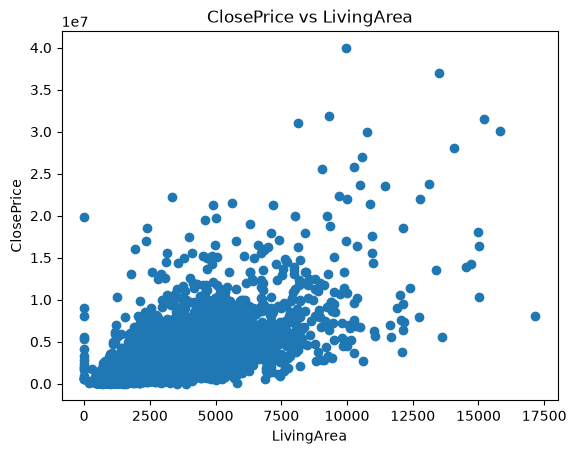

In [23]:
# remove some values to view relationship more clearly
df_closeprice_removed = df[df['ClosePrice'] <= 6 * 10**7]
df_livingarea = df_closeprice_removed[df_closeprice_removed['LivingArea'] <= 20000]

plt.title('ClosePrice vs LivingArea')
plt.xlabel('LivingArea')
plt.ylabel('ClosePrice')
plt.scatter(df_livingarea['LivingArea'], df_livingarea['ClosePrice']);

##### BedroomsTotal

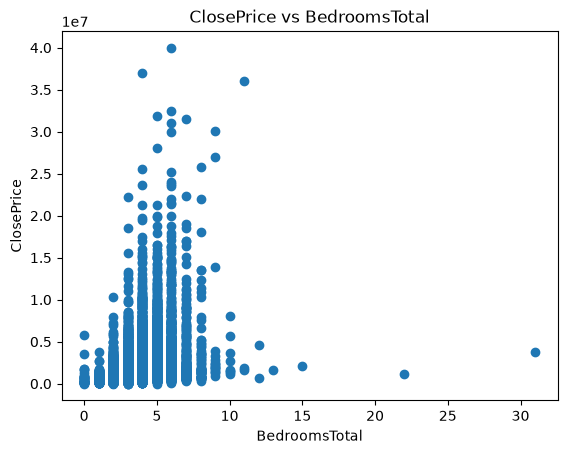

In [24]:
plt.title('ClosePrice vs BedroomsTotal')
plt.xlabel('BedroomsTotal')
plt.ylabel('ClosePrice')
plt.scatter(df_closeprice_removed['BedroomsTotal'], df_closeprice_removed['ClosePrice']);

##### BathroomsTotalInteger

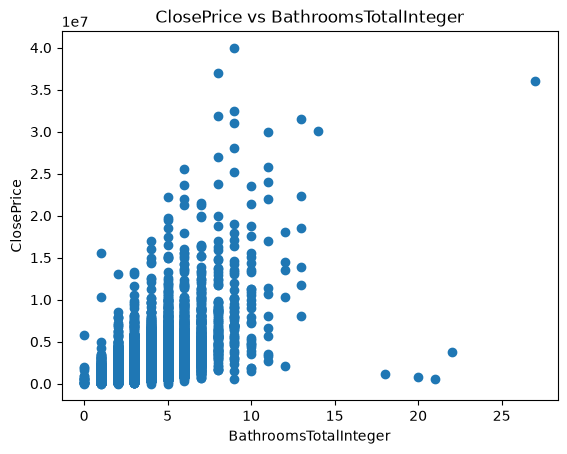

In [25]:
# remove some extreme values to view relationship
df_bathrooms = df_closeprice_removed[df_closeprice_removed['BathroomsTotalInteger'] <= 50]

plt.title('ClosePrice vs BathroomsTotalInteger')
plt.xlabel('BathroomsTotalInteger')
plt.ylabel('ClosePrice')
plt.scatter(df_bathrooms['BathroomsTotalInteger'], df_bathrooms['ClosePrice']);

##### LotSizeSquareFeet

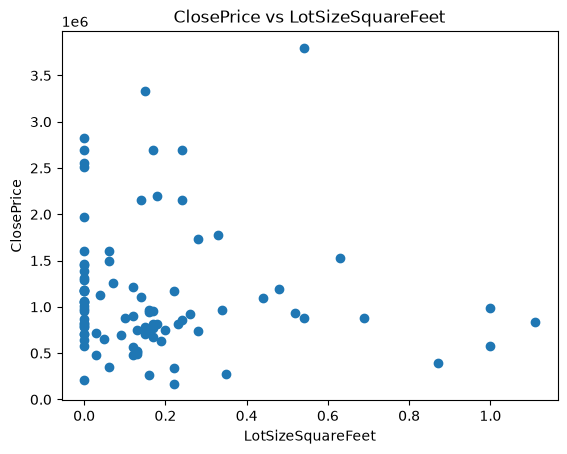

In [ ]:
# remove some values - these are not as extreme outliers
df_lotsize = df_closeprice_removed[df_closeprice_removed['LotSizeSquareFeet'] <= 1.25]

plt.title('ClosePrice vs LotSizeSquareFeet')
plt.xlabel('LotSizeSquareFeet')
plt.ylabel('ClosePrice')
plt.scatter(df_lotsize['LotSizeSquareFeet'], df_lotsize['ClosePrice']);

For later, we might want to analyze the consequence of removing these values. What do these extreme values represent and is it okay to remove them?

We also might want to explore other ways of viewing these relationships. Maybe we should plot a regression line?